# Neural Network Modeling Pipeline

This notebook develops and evaluates a feedforward neural network for binary water quality classification. The primary objective is to identify the most influential factors affecting water quality while achieving reliable predictive performance and improving the interpretability of the neural network.

A feedforward neural network is chosen because water quality depends on multiple physicochemical variables whose relationships with the target may be highly nonlinear. Compared with traditional machine learning models, neural networks can automatically learn complex feature representations and capture interactions among variables without explicitly specifying them, making them suitable for modeling water quality classification problems.

The notebook follows a complete supervised machine learning workflow consisting of data preparation, model development, optimization, evaluation, and interpretation.

### Workflow Overview

1. **Import Libraries**
   Import all required libraries for data preprocessing, neural network modeling, evaluation, visualization, and model interpretation.

2. **Load Dataset**
   Load the cleaned water quality dataset.

3. **Data Preparation**
   Prepare the feature matrix and target variable, and encode categorical variables using Ordinal Encoding (Color) and One-Hot Encoding (Source).

4. **Train–Test Split**
   Split the dataset into training and testing sets using stratified sampling to preserve the class distribution.

5. **Feature Scaling**
   Standardize the input features using StandardScaler to improve neural network training stability.

6. **Handle Imbalanced Data**
   Compute class weights from the training data to reduce bias toward the majority class.

7. **Build Neural Network**
   Construct a configurable feedforward neural network architecture that supports different optimizers and hidden layer sizes.

8. **Baseline Neural Network**
   Train an initial neural network using a baseline hyperparameter configuration and evaluate its predictive performance.

9. **Hyperparameter Tuning**
   Perform Stratified 5-Fold Cross Validation to identify the optimal optimizer, learning rate, and hidden layer size based on the mean ROC-AUC score.

10. **Train Final Neural Network**
    Retrain the neural network using the optimal hyperparameters selected during cross-validation.

11. **Final Model Evaluation**
    Present the final model configuration, evaluate the model using multiple classification metrics, compare it with the baseline model, and analyze the training history through the loss curves.

12. **Model Interpretation**
    Interpret the trained neural network using permutation importance analysis, including:

    - **Single-Feature Permutation Importance**, which identifies the individual contribution of each feature.
    - **Pairwise Permutation Importance**, which investigates the joint contribution and potential interactions among the most important features.

Throughout the notebook, each modeling step is accompanied by explanations of the methodology, parameter choices, and experimental results to provide a transparent and interpretable neural network modeling process.

### Step 1：Import libraries

In [9]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop

# Others
from itertools import combinations

### Step 2：Load dataset

In [10]:
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

### Step 3: Data Preparation

In [11]:
### 1. Data Preparation
X_nn = df.drop(columns=["Target"])
y_nn = df["Target"]

print("X_nn shape:", X_nn.shape)
print("y_nn shape:", y_nn.shape)

### 2. Categorical Encoding: Color, Source

# Source is an unordered categorical variable,
# so we use One-Hot Encoding.

# Color has a natural order:
# Colorless < Near Colorless < Faint Yellow < Light Yellow < Yellow
# therefore Ordinal Encoding is used.

# Color: Ordinal Encoding

color_order = [
    "Colorless",
    "Near Colorless",
    "Faint Yellow",
    "Light Yellow",
    "Yellow"
]

color_mapping = {
    cat: i
    for i, cat in enumerate(color_order)
}

X_nn["Color"] = X_nn["Color"].map(color_mapping)

# Source: One-Hot Encoding

X_nn = pd.get_dummies(
    X_nn,
    columns=["Source"],
    drop_first=False
)

print("X_nn shape after encoding:", X_nn.shape)
print(X_nn.columns.tolist())

X_nn shape: (734756, 22)
y_nn shape: (734756,)
X_nn shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


### Step 4: Train-Test Split

In [12]:
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn,
    y_nn,
    test_size=0.2,
    random_state=42,
    stratify=y_nn
)

print("X_train_nn shape:", X_train_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)
print("y_train_nn shape:", y_train_nn.shape)
print("y_test_nn shape:", y_test_nn.shape)

X_train_nn shape: (587804, 29)
X_test_nn shape: (146952, 29)
y_train_nn shape: (587804,)
y_test_nn shape: (146952,)


### Step 5: Feature Scaling

Feature scaling is applied before training the neural network to ensure that all input features are on a comparable scale. Since neural networks are optimized using gradient-based algorithms, large differences in feature magnitudes may slow convergence and reduce training stability.

The StandardScaler is fitted only on the training set and then applied to the test set to prevent data leakage.

In [ ]:
# Standardize features using statistics calculated
# from the training set only to avoid data leakage.

# Initialize the scaler
scaler = StandardScaler()

# Fit on the training set only
X_train_scaled_nn = scaler.fit_transform(X_train_nn)

# Apply the same transformation to the test set
X_test_scaled_nn = scaler.transform(X_test_nn)

print("X_train_scaled_nn shape:", X_train_scaled_nn.shape)
print("X_test_scaled_nn shape:", X_test_scaled_nn.shape)

### Step 6: Handle Imbalanced Data

To reduce the effect of class imbalance, class weights are computed from the training data and applied during model training. This encourages the neural network to pay more attention to the minority class.

In [13]:
# Compute class weights based on the class distribution
# in the training set. The "balanced" option automatically
# assigns higher weights to minority classes.
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_nn),   # All class labels (0 and 1)
    y=y_train_nn                     # Training labels
)

# Convert the returned array into a dictionary
# required by Keras model.fit(class_weight=...)
class_weight = {
    0: weights[0],   # Weight assigned to class 0
    1: weights[1]    # Weight assigned to class 1
}

### Step 7: Build Neural Network

A feedforward neural network is constructed for binary water quality classification. The model consists of an input layer, two fully connected hidden layers with ReLU activation, and a sigmoid output layer that predicts the probability of a water sample belonging to the positive class. The optimizer is passed as a parameter to allow different optimization algorithms to be evaluated during hyperparameter tuning.

In [14]:
# Build a configurable feed-forward neural network.
#
# The network architecture consists of:
# - One input layer
# - Two fully connected hidden layers with ReLU activation
# - One sigmoid output layer for binary classification
#
# The number of hidden units and optimizer are provided
# as function arguments, allowing different hyperparameter
# combinations to be evaluated during cross-validation.
# ---------------------------------------------------------

def build_model(hidden_units, optimizer):

    # Create a sequential neural network model
    model = Sequential()

    # Input layer
    # The input dimension equals the number of features
    # in the training dataset.
    model.add(Input(shape=(X_train_nn.shape[1],)))

    # First hidden layer
    # ReLU activation introduces non-linearity and helps
    # the model learn complex relationships between features.
    model.add(Dense(hidden_units, activation="relu"))

    # Second hidden layer
    # Use half the neurons of the first hidden layer to
    # gradually reduce the feature representation.
    model.add(Dense(hidden_units // 2, activation="relu"))

    # Output layer
    # Sigmoid activation outputs a probability between
    # 0 and 1 for binary classification.
    model.add(Dense(1, activation="sigmoid"))

    # Compile model
    # Binary cross-entropy is used as the loss function
    # for binary classification, while accuracy is tracked
    # during training as an evaluation metric.
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model
    return model

**Network Architecture**

Input Layer → Dense(hidden_units, ReLU) → Dense(hidden_units / 2, ReLU) → Dense(1, Sigmoid)

### Step 8: Baseline Neural Network


A baseline neural network is first established to provide a reference model before applying hyperparameter tuning. The baseline uses a simple fully connected architecture with commonly adopted default settings, allowing the performance improvements achieved in later experiments to be evaluated objectively.

#### Model Architecture
The neural network contains one hidden layer with **64 neurons** followed by an output layer with a sigmoid activation function.

- **64 hidden units** were selected as a moderate network size. It provides sufficient capacity to learn nonlinear relationships in the dataset while reducing the risk of overfitting compared with larger networks.
- A **sigmoid activation** is used in the output layer because this is a binary classification problem, where the model predicts the probability that a water sample belongs to the positive class.

#### Optimizer
The model is trained using the **Adam optimizer** with a learning rate of **0.001**.

- Adam is widely used for neural network optimization because it combines adaptive learning rates with momentum, leading to faster and more stable convergence than standard gradient descent.
- A learning rate of **0.001** is the default value recommended for Adam and generally provides a good balance between convergence speed and training stability.

#### Training Strategy

Several techniques are applied during training to improve model generalization:

- **Early Stopping (patience = 5)** monitors the validation loss and stops training when no improvement is observed for five consecutive epochs. This helps prevent overfitting while reducing unnecessary computation.
- **25 training epochs** are chosen as the maximum training length. Since Early Stopping is enabled, the model usually terminates before reaching all 25 epochs if convergence occurs earlier.
- **Batch size = 32** is a commonly used setting that provides a good trade-off between computational efficiency and gradient stability.
- **Validation split = 0.2** reserves 20% of the training data for validation, allowing model performance to be monitored during training.
- **Class weights** are incorporated to compensate for the class imbalance in the dataset, encouraging the model to pay more attention to the minority class.

#### Classification Threshold

Although the sigmoid output produces probabilities between 0 and 1, a threshold of **0.3** is used instead of the default **0.5** when converting probabilities into class labels.

The primary objective of this project is to identify unsafe water samples. Missing an unsafe sample (false negative) is generally more serious than incorrectly classifying a safe sample as unsafe (false positive). Lowering the threshold increases recall for the positive class, making the model more sensitive to potentially unsafe water samples.

#### Model Evaluation

The baseline model is evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, the Classification Report, and the Confusion Matrix.

Using multiple evaluation metrics provides a more comprehensive assessment than accuracy alone, particularly when class imbalance exists.

In [15]:
### Step 8: Baseline Neural Network

# Early Stopping
# Stop training early if the validation loss
# does not improve for 5 consecutive epochs.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Build the baseline neural network using
# the initial hyperparameter settings.
baseline_model = build_model(
    hidden_units=64,
    optimizer=Adam(learning_rate=0.001)
)

# Train model
# Train the neural network on the standardized training data.
# A validation subset is used for Early Stopping,
# and class weights are applied to reduce class imbalance.
history = baseline_model.fit(
    X_train_scaled_nn,
    y_train_nn,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0
)

# Predict probabilities
# Predict the probability of each test sample
# belonging to the positive class.
y_prob_nn = baseline_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()

# Convert probability to class
# Convert predicted probabilities into binary class labels.
# A threshold of 0.3 is used to improve recall
# for identifying unsafe water samples.
threshold = 0.3
y_pred_nn = (y_prob_nn >= threshold).astype(int)

# Evaluation metrics
accuracy = accuracy_score(y_test_nn, y_pred_nn)
precision = precision_score(y_test_nn, y_pred_nn)
recall = recall_score(y_test_nn, y_pred_nn)
f1 = f1_score(y_test_nn, y_pred_nn)
roc_auc = roc_auc_score(y_test_nn, y_prob_nn)

print("========== Baseline Model ==========")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report")
print(classification_report(y_test_nn, y_pred_nn))

cm = confusion_matrix(y_test_nn, y_pred_nn)

print("\nConfusion Matrix")
print(cm)

========== Baseline Model ==========
Accuracy: 0.8604
Precision: 0.6265
Recall: 0.9751
F1 Score: 0.7628
ROC-AUC: 0.9158

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.83      0.90    113127
           1       0.63      0.98      0.76     33825

    accuracy                           0.86    146952
   macro avg       0.81      0.90      0.83    146952
weighted avg       0.91      0.86      0.87    146952


Confusion Matrix
[[93459 19668]
 [  841 32984]]


#### Results Interpretation

The baseline neural network achieved an **accuracy of 86.04%**, indicating that the model correctly classified the majority of water samples. In addition, the **ROC-AUC of 0.9158** demonstrates excellent discrimination between safe and unsafe water samples, suggesting that the model can effectively rank positive and negative cases.

The model achieved a **recall of 97.51%** for the positive class (unsafe water), meaning that nearly all unsafe water samples were successfully detected. This is particularly important because failing to identify contaminated water (false negatives) could have more serious consequences than incorrectly classifying a safe sample as unsafe.

However, the **precision was 62.65%**, which is noticeably lower than the recall. This indicates that although the model detects most unsafe samples, it also produces a relatively large number of false positives. This trade-off is expected because a lower classification threshold (0.3 instead of the default 0.5) was intentionally chosen to prioritize recall.

The **F1-score of 0.7628** reflects a reasonable balance between precision and recall. Although precision is moderate, the high recall leads to an acceptable overall performance for identifying unsafe water samples.

The confusion matrix further supports these observations:

- **True Negatives (TN): 93,459** safe water samples were correctly classified.
- **False Positives (FP): 19,668** safe water samples were incorrectly classified as unsafe.
- **False Negatives (FN): 841** unsafe water samples were missed.
- **True Positives (TP): 32,984** unsafe water samples were correctly identified.

Only **841 unsafe water samples** were misclassified as safe, demonstrating that the model is highly sensitive to contaminated water. Although the number of false positives is relatively high, this trade-off is acceptable because the primary objective of this project is to minimize the risk of overlooking unsafe water samples.

Overall, the baseline neural network provides strong predictive performance and serves as an effective benchmark for the subsequent hyperparameter tuning process.

**Baseline Model Configuration**

- Hidden units: 64
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 32
- Maximum epochs: 25
- Early stopping: patience = 5
- Classification threshold: 0.3

### Step 9: Hyperparameter Tuning (5-Fold Cross Validation)

After establishing the baseline neural network, hyperparameter tuning is performed to improve the model's predictive performance. Neural networks are highly sensitive to hyperparameter settings, and different configurations may produce substantially different results. Therefore, a systematic search is conducted to identify the combination that achieves the best generalization performance.

#### Hyperparameters Evaluated

Three important hyperparameters are considered:

- **Optimizer**
  - Adam
  - RMSprop

Both optimizers are adaptive gradient-based optimization algorithms that are widely used for neural networks. Adam combines momentum with adaptive learning rates, while RMSprop adapts the learning rate based on recent gradients. Comparing both optimizers allows us to evaluate which optimization strategy is more suitable for this dataset.

- **Learning Rate**
  - 0.001
  - 0.0005

The learning rate controls the size of parameter updates during training. A larger learning rate generally leads to faster convergence but may overshoot the optimum, whereas a smaller learning rate often provides more stable optimization at the cost of slower training.

- **Hidden Units**
  - 64
  - 128

The number of hidden neurons determines the model capacity. A larger hidden layer can capture more complex nonlinear relationships but may also increase the risk of overfitting. Comparing two network sizes helps determine an appropriate model complexity.

Overall, **8 hyperparameter combinations (2 × 2 × 2)** are evaluated.

#### Why 5-Fold Stratified Cross Validation?

Instead of relying on a single train-validation split, **Stratified 5-Fold Cross Validation** is adopted.

This approach divides the training data into five folds while preserving the class distribution in each fold. During each iteration, four folds are used for training and one fold is used for validation. The process is repeated five times so that every sample serves as the validation data exactly once.

Compared with a single validation split, cross-validation provides a more reliable estimate of model performance by reducing the influence of random sampling.

#### Feature Scaling within Each Fold

A new **StandardScaler** is fitted using only the training subset of each fold.

The fitted scaler is then applied to the corresponding validation subset.

This procedure prevents information from the validation data from leaking into the training process, ensuring that model evaluation remains unbiased.

#### Class Weight for Each Fold

Class weights are recalculated separately for every training fold.

Since the proportion of positive and negative samples may vary slightly across different folds, recalculating class weights enables the model to properly compensate for class imbalance throughout the cross-validation process.

#### Early Stopping

Early Stopping is again applied during each fold.

Training terminates automatically when the validation loss does not improve for five consecutive epochs. This prevents overfitting while reducing unnecessary computation.

#### Evaluation Metric

The performance of each hyperparameter combination is evaluated using the **mean ROC-AUC across the five validation folds**.

ROC-AUC is selected instead of accuracy because it evaluates the model's ability to distinguish between the two classes across all possible classification thresholds. It is also less sensitive to class imbalance than accuracy, making it more appropriate for this water quality classification problem.

Finally, the hyperparameter combination with the highest mean ROC-AUC is selected as the optimal configuration and will be used to train the final neural network model.

In [16]:
### Step 9: Hyperparameter Tuning (5-Fold Cross Validation)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Candidate hyperparameters to be evaluated.
optimizers = {
    "Adam": Adam,
    "RMSprop": RMSprop
}

learning_rates = [0.001, 0.0005]

hidden_units = [64, 128]

# Perform stratified 5-fold cross-validation to
# preserve the class distribution in each fold.
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

# Evaluate every combination of optimizer,
# learning rate, and hidden units
for opt_name, opt_class in optimizers.items():

    for lr in learning_rates:

        for units in hidden_units:

            cv_scores = []

            for train_idx, val_idx in kf.split(X_train_nn, y_train_nn):
                # -----------------------------
                # Split current fold
                # -----------------------------
                X_fold_train = X_train_nn.iloc[train_idx]
                X_fold_val = X_train_nn.iloc[val_idx]

                y_fold_train = y_train_nn.iloc[train_idx]
                y_fold_val = y_train_nn.iloc[val_idx]

                # -----------------------------
                # Feature Scaling (Fit ONLY on fold training set)
                # -----------------------------
                scaler = StandardScaler()

                X_fold_train = scaler.fit_transform(X_fold_train)
                X_fold_val = scaler.transform(X_fold_val)

                # -----------------------------
                # Class Weight (Current Fold)
                # -----------------------------
                weights = compute_class_weight(
                    class_weight="balanced",
                    classes=np.unique(y_fold_train),
                    y=y_fold_train
                )

                class_weight_fold = {
                    0: weights[0],
                    1: weights[1]
                }

                # -----------------------------
                # Build Model
                # -----------------------------
                optimizer = opt_class(
                    learning_rate=lr
                )

                model = build_model(
                    hidden_units=units,
                    optimizer=optimizer
                )

                # -----------------------------
                # Train
                # -----------------------------
                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(
                        X_fold_val,
                        y_fold_val
                    ),
                    callbacks=[early_stop],
                    class_weight=class_weight_fold,
                    verbose=0
                )

                # -----------------------------
                # Validation Prediction
                # -----------------------------
                y_prob_nn = model.predict(
                    X_fold_val,
                    verbose=0
                ).flatten()

                roc_auc = roc_auc_score(
                    y_fold_val,
                    y_prob_nn
                )

                cv_scores.append(roc_auc)

            # -----------------------------
            # Mean CV Score
            # -----------------------------
            mean_auc = np.mean(cv_scores)

            results.append({

                "Optimizer": opt_name,

                "Learning Rate": lr,

                "Hidden Units": units,

                "CV ROC-AUC": mean_auc

            })

            print(
                f"{opt_name} | "
                f"LR={lr} | "
                f"Units={units} | "
                f"Mean CV ROC-AUC={mean_auc:.4f}"
            )

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\n========== Hyperparameter Tuning Results ==========\n")

print(results_df)

best_params = results_df.iloc[0]

print("\nBest Parameters")
print(best_params)

print(
    "\nBest CV ROC-AUC Score:",
    round(best_params["CV ROC-AUC"], 4)
)

Adam | LR=0.001 | Units=64 | Mean CV ROC-AUC=0.9079
Adam | LR=0.001 | Units=128 | Mean CV ROC-AUC=0.9079
Adam | LR=0.0005 | Units=64 | Mean CV ROC-AUC=0.9051
Adam | LR=0.0005 | Units=128 | Mean CV ROC-AUC=0.9060
RMSprop | LR=0.001 | Units=64 | Mean CV ROC-AUC=0.9054
RMSprop | LR=0.001 | Units=128 | Mean CV ROC-AUC=0.9081
RMSprop | LR=0.0005 | Units=64 | Mean CV ROC-AUC=0.9041
RMSprop | LR=0.0005 | Units=128 | Mean CV ROC-AUC=0.9058

========== Hyperparameter Tuning Results ==========

  Optimizer  Learning Rate  Hidden Units  CV ROC-AUC
0   RMSprop         0.0010           128    0.908075
1      Adam         0.0010            64    0.907937
2      Adam         0.0010           128    0.907865
3      Adam         0.0005           128    0.905999
4   RMSprop         0.0005           128    0.905845
5   RMSprop         0.0010            64    0.905440
6      Adam         0.0005            64    0.905053
7   RMSprop         0.0005            64    0.904065

Best Parameters
Optimizer       

#### Results Interpretation

Eight hyperparameter combinations were evaluated using Stratified 5-Fold Cross Validation. The mean ROC-AUC values ranged from **0.9041 to 0.9081**, indicating that all configurations achieved relatively stable performance.

Among the evaluated combinations, **RMSprop with a learning rate of 0.001 and 128 hidden units** achieved the highest mean cross-validation ROC-AUC of **0.9081**. Therefore, this configuration was selected for training the final neural network.

The results also show that the differences among the eight configurations are relatively small (less than 0.005 in ROC-AUC). This suggests that the baseline neural network already provides strong performance, and the model is relatively robust to moderate changes in these hyperparameters.

Comparing the optimizers, **RMSprop slightly outperformed Adam** under the best configuration, although the improvement was marginal. Increasing the number of hidden units from **64 to 128** generally resulted in a small improvement, indicating that a slightly larger network is able to capture more complex relationships within the data.

Overall, hyperparameter tuning identified a slightly better-performing configuration while confirming that the neural network exhibits stable performance across different parameter settings.

### Step 10: Train Final Neural Network

After identifying the optimal hyperparameter combination through Stratified 5-Fold Cross Validation, the final neural network is trained using the complete training dataset.

Unlike the previous cross-validation stage, where the objective was to compare different hyperparameter combinations, this step aims to build the final prediction model using the selected configuration and evaluate its performance on the independent test set.

#### Selected Hyperparameters

The final model uses the hyperparameter combination that achieved the highest mean cross-validation ROC-AUC:

- **Optimizer:** RMSprop
- **Learning Rate:** 0.001
- **Hidden Units:** 128

These hyperparameters were selected because they provided the best generalization performance during cross-validation.

#### Feature Scaling

A new **StandardScaler** is fitted using the entire training dataset and then applied to the test dataset.

Since neural networks are sensitive to differences in feature scales, standardization improves training stability and accelerates convergence.

Importantly, the scaler is fitted **only on the training data** before transforming the test data, preventing information leakage.

#### Model Training

The final neural network is trained using the entire training dataset with the selected hyperparameters.

The following training strategy is adopted:

- **Batch size = 32** provides a balance between computational efficiency and stable gradient estimation.
- **Maximum epochs = 25** allow sufficient learning while relying on Early Stopping to determine the optimal stopping point.
- **Validation split = 0.2** reserves 20% of the training data for monitoring validation performance during training.
- **Early Stopping (patience = 5)** prevents overfitting by restoring the weights corresponding to the lowest validation loss.
- **Class weights** are used to compensate for class imbalance and improve the model's ability to detect unsafe water samples.

#### Model Evaluation

After training, the final model predicts the probability that each test sample belongs to the positive class.

A classification threshold of **0.3** is again adopted to prioritize the detection of unsafe water samples.

The final model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification Report
- Confusion Matrix

Using multiple evaluation metrics provides a comprehensive assessment of the model performance from different perspectives.

#### Training History

Finally, the training and validation loss curves are visualized.

These curves help evaluate whether the model converges successfully during training and whether overfitting occurs. The epoch corresponding to the minimum validation loss is highlighted because it represents the model selected by Early Stopping.

========== Final Model ==========
Optimizer: RMSprop
Learning Rate: 0.001
Hidden Units: 128

========== Final Model Performance ==========

Accuracy: 0.8669
Precision: 0.6425
Recall: 0.9506
F1 Score: 0.7668
ROC-AUC: 0.9129

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.84      0.91    113127
           1       0.64      0.95      0.77     33825

    accuracy                           0.87    146952
   macro avg       0.81      0.90      0.84    146952
weighted avg       0.90      0.87      0.87    146952


Confusion Matrix

[[95237 17890]
 [ 1670 32155]]


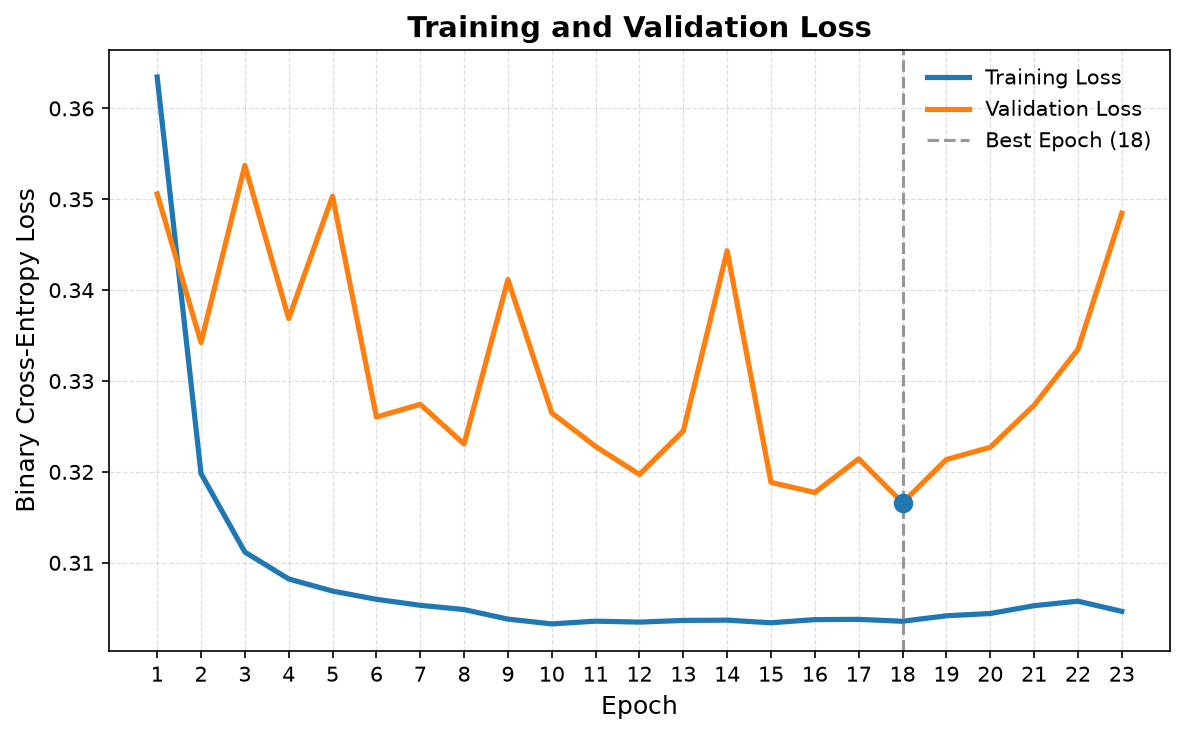

In [17]:
### Step 10: Train Final Model

# -----------------------------
# Get Best Hyperparameters
# -----------------------------

best_optimizer_name = best_params["Optimizer"]
best_lr = best_params["Learning Rate"]
best_hidden_units = int(best_params["Hidden Units"])

print("========== Final Model ==========")
print(f"Optimizer: {best_optimizer_name}")
print(f"Learning Rate: {best_lr}")
print(f"Hidden Units: {best_hidden_units}")

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_train_scaled_nn = scaler.fit_transform(X_train_nn)
X_test_scaled_nn = scaler.transform(X_test_nn)

# -----------------------------
# Build Optimizer
# -----------------------------

optimizer_dict = {
    "Adam": Adam,
    "RMSprop": RMSprop
}

optimizer = optimizer_dict[best_optimizer_name](
    learning_rate=best_lr
)

# -----------------------------
# Build Final Model
# -----------------------------

final_model = build_model(
    hidden_units=best_hidden_units,
    optimizer=optimizer
)

# -----------------------------
# Early Stopping
# -----------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train
# -----------------------------
# Train the final model on the entire training set.
# A validation subset is used for Early Stopping,
# while class weights reduce the impact of class imbalance.

history = final_model.fit(

    X_train_scaled_nn,
    y_train_nn,

    epochs=25,

    batch_size=32,

    validation_split=0.2,

    class_weight=class_weight,

    callbacks=[early_stop],

    verbose=0
)

# -----------------------------
# Prediction
# -----------------------------

y_prob_nn = final_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()
# Convert predicted probabilities into class labels.
# A threshold of 0.3 is used to improve recall
# for detecting unsafe water samples.
threshold = 0.3

y_pred_nn = (y_prob_nn >= threshold).astype(int)

# -----------------------------
# Evaluation
# -----------------------------

accuracy = accuracy_score(
    y_test_nn,
    y_pred_nn
)

precision = precision_score(
    y_test_nn,
    y_pred_nn
)

recall = recall_score(
    y_test_nn,
    y_pred_nn
)

f1 = f1_score(
    y_test_nn,
    y_pred_nn
)

roc_auc = roc_auc_score(
    y_test_nn,
    y_prob_nn
)

print("\n========== Final Model Performance ==========\n")

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report\n")

print(classification_report(
    y_test_nn,
    y_pred_nn
))

print("\nConfusion Matrix\n")

print(confusion_matrix(
    y_test_nn,
    y_pred_nn
))

# -----------------------------
# Plot Training History
# -----------------------------

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)

best_epoch = np.argmin(val_loss) + 1
best_val_loss = np.min(val_loss)

plt.figure(figsize=(8, 5), dpi=150)

# Training loss
plt.plot(
    epochs,
    train_loss,
    linewidth=2.5,
    label="Training Loss"
)

# Validation loss
plt.plot(
    epochs,
    val_loss,
    linewidth=2.5,
    label="Validation Loss"
)

# Best epoch
plt.axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label=f"Best Epoch ({best_epoch})"
)

# Highlight minimum validation loss
plt.scatter(
    best_epoch,
    best_val_loss,
    s=70,
    zorder=5
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)

plt.title(
    "Training and Validation Loss",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(epochs)

plt.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.4
)

plt.legend(frameon=False)

plt.tight_layout()

plt.show()

**Final Model Configuration**

| Hyperparameter | Value |
|----------------|-------|
| Optimizer | Selected by Cross Validation |
| Learning Rate | Best value from tuning |
| Hidden Units | Best value from tuning |
| Batch Size | 32 |
| Maximum Epochs | 25 |
| Early Stopping | Patience = 5 |
| Classification Threshold | 0.3 |
| Evaluation Metric | Accuracy, Precision, Recall, F1-score, ROC-AUC |

#### Final Model Configuration

The final neural network configuration was determined based on the hyperparameter tuning results.

The optimizer, learning rate, and hidden layer size were selected because they achieved the highest mean ROC-AUC during Stratified 5-Fold Cross Validation.

Other training settings, including the batch size, maximum number of epochs, Early Stopping strategy, and classification threshold, were kept consistent with the baseline model to ensure a fair comparison.

Therefore, any performance differences between the baseline and the final model can mainly be attributed to the optimized hyperparameters rather than changes in the training procedure.

#### Results Interpretation

The final neural network achieved an **accuracy of 86.69%**, indicating that the model correctly classified the majority of water samples.

The **ROC-AUC reached 0.9129**, demonstrating excellent discriminative ability between safe and unsafe water samples.

The model achieved a **recall of 95.06%** for unsafe water samples, indicating that most contaminated water samples were successfully detected.

Although the recall is slightly lower than that of the baseline model, the **precision increased from 62.65% to 64.25%**, meaning that fewer safe water samples were incorrectly classified as unsafe.

Similarly, the **F1-score increased from 0.7628 to 0.7668**, suggesting a better balance between precision and recall.

Overall, the final model achieves a more balanced prediction performance while maintaining a very high capability for detecting unsafe water samples.

#### Comparison with the Baseline Model

Compared with the baseline neural network, the final model achieved improvements in **accuracy**, **precision**, and **F1-score**, indicating a better overall balance between correctly identifying unsafe water samples and reducing false alarms.

The **recall** decreased slightly from **97.51%** to **95.06%**, meaning that the final model missed a small number of additional unsafe water samples. However, this reduction was accompanied by an increase in precision, suggesting that the model generated fewer false positive predictions.

Similarly, the ROC-AUC decreased only marginally (0.9158 to 0.9129), indicating that the overall discriminative ability remained excellent.

Overall, hyperparameter tuning produced a more balanced classifier with slightly higher overall predictive performance while maintaining a very high recall for unsafe water detection.

#### Training History

The training and validation loss curves show that the model converges rapidly during the first several epochs.

The training loss decreases steadily before stabilizing, indicating that the neural network successfully learns meaningful patterns from the training data.

The validation loss fluctuates slightly throughout the training process but reaches its minimum value at **Epoch 18**, after which it begins to increase gradually.

This behavior suggests that additional training beyond Epoch 18 does not improve the model's generalization ability and may lead to overfitting.

The Early Stopping mechanism successfully identifies this point and restores the model parameters corresponding to the lowest validation loss, ensuring that the final model achieves the best generalization performance.

### Step 11: Permutation Importance

Permutation importance is used to interpret the trained neural network by measuring the contribution of each feature to model performance. The importance of a feature is estimated by randomly permuting its values in the test set and observing the decrease in ROC-AUC. Features causing a larger performance drop are considered more influential for water quality prediction.

In addition to single-feature importance, pairwise permutation analysis is performed to investigate potential interactions between the most important features.

### Step 11.1: Single Feature Permutation Importance

Although neural networks often achieve strong predictive performance, they are generally regarded as "black-box" models because the relationship between the input variables and the final prediction is difficult to interpret directly.

To better understand how the trained neural network makes predictions, **Permutation Importance** is applied.

Permutation Importance estimates the contribution of each feature by randomly shuffling its values in the test dataset while keeping all other features unchanged.

If shuffling a feature causes a large decrease in the model's performance, it indicates that the model relies heavily on that feature. Conversely, if model performance changes only slightly, the feature contributes relatively little to the prediction.

In this study, feature importance is measured using the **decrease in ROC-AUC**, which reflects the loss of the model's discriminative ability after each feature is permuted.

#### Why ROC-AUC?

ROC-AUC is selected because it evaluates the model's ability to distinguish between safe and unsafe water samples across all possible classification thresholds. Compared with accuracy, ROC-AUC is less affected by class imbalance and therefore provides a more reliable measure of feature importance.

#### Why Repeat the Permutation Five Times?

Random permutation introduces sampling variability.

To reduce randomness, each feature is permuted **five times**, and the average decrease in ROC-AUC is used as its final importance score.

This produces a more stable and reliable estimate of feature importance.

#### Why Are Source Variables Permuted Together?

The categorical variable **Source** is represented using multiple one-hot encoded columns.

If each one-hot column were permuted independently, invalid category combinations could be created (for example, multiple source categories becoming active simultaneously).

Therefore, all one-hot encoded Source columns are shuffled together as a single feature, preserving the original categorical structure while measuring its overall importance.


      Feature  Importance
14  Manganese    0.052725
0          pH    0.041587
7   Turbidity    0.037196
9      Copper    0.032697
3    Chloride    0.029549
1        Iron    0.026977
2     Nitrate    0.018830
10       Odor    0.015956
8    Fluoride    0.015796
13   Chlorine    0.014944


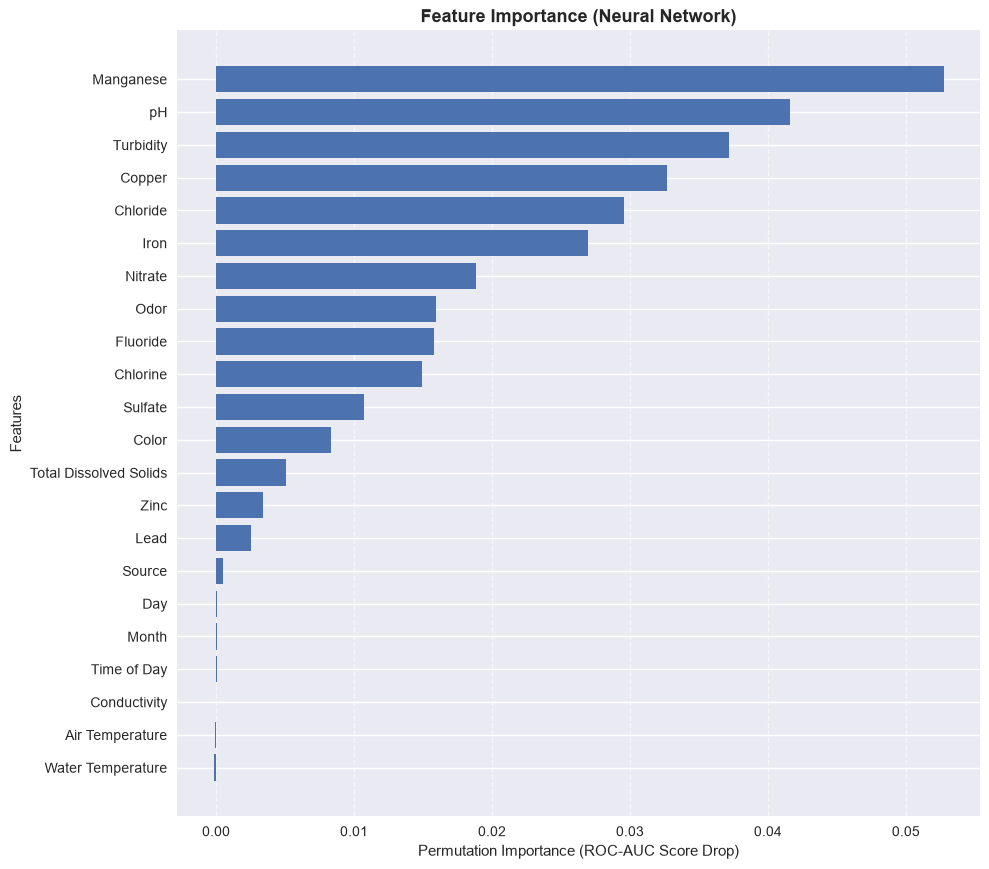

In [21]:
# -------------------------------
# Step 1: Compute baseline performance
# -------------------------------

# Predict probabilities on the original test set
baseline_prob = final_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()

baseline_score = roc_auc_score(
    y_test_nn,
    baseline_prob
)

importances = []
n_repeats = 5

# -------------------------------
# Identify Source columns
# -------------------------------

source_cols = [
    col for col in X_train_nn.columns
    if col.startswith("Source_")
]

source_idx = [
    X_train_nn.columns.get_loc(col)
    for col in source_cols
]

# -------------------------------
# Step 2: Permutation Importance
# -------------------------------

processed_source = False

for i, col in enumerate(X_train_nn.columns):

    # Skip individual Source columns
    if col.startswith("Source_"):

        # Only calculate Source once
        if processed_source:
            continue

        scores = []

        for _ in range(n_repeats):
            X_permuted = X_test_scaled_nn.copy()

            shuffle_idx = np.random.permutation(len(X_permuted))

            # Shuffle ALL Source columns together
            X_permuted[:, source_idx] = X_permuted[
                shuffle_idx
            ][:, source_idx]

            perm_prob = final_model.predict(
                X_permuted,
                verbose=0
            ).flatten()

            perm_score = roc_auc_score(
                y_test_nn,
                perm_prob
            )

            scores.append(
                baseline_score - perm_score
            )

        importance = np.mean(scores)

        importances.append(
            ("Source", importance)
        )

        processed_source = True

    else:

        scores = []

        for _ in range(n_repeats):
            X_permuted = X_test_scaled_nn.copy()

            shuffle_idx = np.random.permutation(
                len(X_permuted)
            )

            # Shuffle one feature
            X_permuted[:, i] = X_permuted[
                shuffle_idx,
                i
            ]

            perm_prob = final_model.predict(
                X_permuted,
                verbose=0
            ).flatten()

            perm_score = roc_auc_score(
                y_test_nn,
                perm_prob
            )

            scores.append(
                baseline_score - perm_score
            )

        importance = np.mean(scores)

        importances.append(
            (col, importance)
        )

# -------------------------------
# Step 3: Convert to DataFrame
# -------------------------------

importance_df = pd.DataFrame(
    importances,
    columns=[
        "Feature",
        "Importance"
    ]
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

# -------------------------------
# Step 4: Plot
# -------------------------------

plot_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.style.use("seaborn-v0_8")

plt.figure(
    figsize=(10, len(plot_df) * 0.4)
)

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"]
)

plt.xlabel(
    "Permutation Importance (ROC-AUC Score Drop)",
    fontsize=11
)

plt.ylabel(
    "Features",
    fontsize=11
)

plt.title(
    "Feature Importance (Neural Network)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()

#### Results Interpretation：Single Feature Permutation

The permutation importance results rank all input features according to their contribution to the predictive performance of the neural network. A larger importance score indicates that randomly shuffling the feature causes a greater decrease in ROC-AUC, meaning that the model relies more heavily on that feature when making predictions.

Among all variables, **Manganese** is identified as the most influential predictor, with the highest importance score (**0.0527**). This indicates that permuting the Manganese values produces the largest reduction in model performance, suggesting that it provides the most useful information for distinguishing between safe and unsafe water samples.

The second most important feature is **pH (0.0416)**, followed by **Turbidity (0.0372)**, **Copper (0.0327)**, **Chloride (0.0295)**, and **Iron (0.0270)**. These variables consistently contribute to the model's predictions and appear to be the key physicochemical indicators associated with water quality.

A second group of variables, including **Nitrate**, **Odor**, **Fluoride**, **Chlorine**, and **Sulfate**, shows moderate importance. Although these features contribute less than the top-ranked variables, they still improve the predictive performance of the neural network and therefore provide complementary information.

In contrast, **Color**, **Total Dissolved Solids (TDS)**, **Zinc**, **Lead**, and **Source** have relatively low importance scores. Furthermore, the temporal variables (**Day**, **Month**, and **Time of Day**) contribute almost nothing to the prediction, as their permutation produces almost no change in ROC-AUC.

Overall, the results indicate that the neural network mainly relies on a small number of physicochemical measurements, particularly **Manganese, pH, Turbidity, Copper, Chloride, and Iron**, while the time-related variables provide little additional predictive information.

These findings directly answer the project's research question by identifying the strongest predictors of water quality within the neural network model.

The permutation importance results are broadly consistent with the earlier correlation analysis. Features such as Manganese, Turbidity, Copper, Chloride, and Iron were identified as important by both methods, increasing confidence that these variables are genuinely strong predictors of water quality rather than artifacts of a particular analysis technique.

Interestingly, pH is ranked as the second most important feature by permutation importance, despite not having the highest linear correlation with the target variable. This suggests that the neural network is able to capture nonlinear relationships and interactions involving pH that are not reflected by simple correlation analysis.

### Step 11.2: Pairwise Permutation Importance

The previous permutation importance analysis evaluates the contribution of each feature individually. However, neural networks are capable of learning complex nonlinear relationships and interactions among multiple variables.

Therefore, an additional **pairwise permutation importance analysis** is performed to investigate whether combinations of important features jointly contribute to the model's predictions.

Instead of permuting one feature at a time, two features are randomly shuffled simultaneously. If the decrease in ROC-AUC is substantially larger than that observed for either feature individually, it suggests that the neural network relies on the interaction between these variables rather than treating them independently.

#### Why Only the Top Five Features?

Evaluating every possible pair among all variables would require a large number of permutations and substantially increase the computational cost.

Therefore, only the **five most important features identified by the single-feature permutation analysis** are selected.

Since these variables contribute the most to the model individually, they are also the most likely to exhibit meaningful interactions.

This strategy significantly reduces computation while focusing on the most informative feature combinations.

#### Why Shuffle Two Features Simultaneously?

Both selected features are permuted using the same randomly generated permutation index while all remaining variables remain unchanged.

This removes the information contained in both variables simultaneously, allowing the importance of their combined contribution to be evaluated.

#### Why Repeat the Permutation Five Times?

Random permutation introduces variability in the estimated importance.

Each feature pair is therefore permuted **five times**, and the average decrease in ROC-AUC is used as the final interaction importance score.

This reduces the influence of randomness and provides more stable estimates.

#### Visualization

The resulting importance scores are displayed using a horizontal bar chart.

Feature pairs producing larger decreases in ROC-AUC are considered to have stronger joint contributions to the neural network predictions.

             Feature Pair  Importance
0         (Manganese, pH)    0.091840
1  (Manganese, Turbidity)    0.084985
2     (Manganese, Copper)    0.080593
3   (Manganese, Chloride)    0.078554
4         (pH, Turbidity)    0.077794
5            (pH, Copper)    0.073397
6          (pH, Chloride)    0.071940
7     (Turbidity, Copper)    0.066551
8   (Turbidity, Chloride)    0.064265
9      (Copper, Chloride)    0.060408


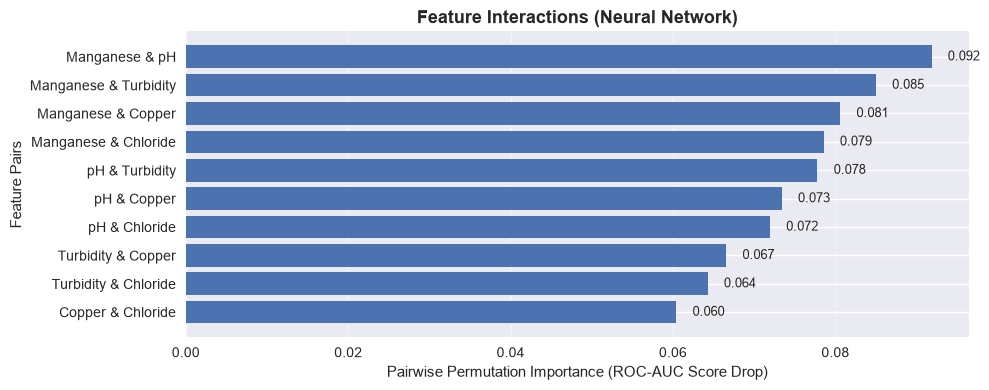

In [22]:
# -------------------------------
# Step 1: Compute baseline performance
# -------------------------------

# Predict probabilities on the original test set
baseline_prob = final_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()

baseline_score = roc_auc_score(
    y_test_nn,
    baseline_prob
)

pair_importances = []
#Only the five most important features from the previous analysis are selected.
#This focuses the interaction analysis on the variables that contribute most strongly to the model while keeping the computational complexity manageable.
n_repeats = 5  # number of repetitions to reduce randomness

# -------------------------------
# Step 2: Select top features based on single permutation
# -------------------------------

feature_names = list(X_train_nn.columns)

top_features = importance_df.head(5)["Feature"].values
top_indices = [feature_names.index(f) for f in top_features]

# Generate all pair combinations from top features
pairs = list(combinations(top_indices, 2))

# -------------------------------
# Step 3: Perform pairwise permutation
# -------------------------------

for i, j in pairs:

    scores = []

    for _ in range(n_repeats):
        # Copy the test set
        X_permuted = X_test_scaled_nn.copy()

        # Generate shuffled index
        shuffle_idx = np.random.permutation(len(X_permuted))

        # Shuffle BOTH features
        X_permuted[:, i] = X_permuted[shuffle_idx, i]
        X_permuted[:, j] = X_permuted[shuffle_idx, j]

        # Predict probabilities
        perm_prob = final_model.predict(
            X_permuted,
            verbose=0
        ).flatten()

        perm_score = roc_auc_score(
            y_test_nn,
            perm_prob
        )

        # Compute ROC-AUC drop
        scores.append(baseline_score - perm_score)

    importance = np.mean(scores)

    pair_importances.append((
        (feature_names[i], feature_names[j]),
        importance
    ))

# -------------------------------
# Step 4: Convert results to DataFrame
# -------------------------------

pair_df = pd.DataFrame(
    pair_importances,
    columns=["Feature Pair", "Importance"]
)

pair_df = pair_df.sort_values(
    by="Importance",
    ascending=False
)

print(pair_df.head(10))

# -------------------------------
# Step 5: Prepare data for plotting
# -------------------------------

# Convert tuple (A, B) → "A & B"
pair_df["Pair Name"] = pair_df["Feature Pair"].apply(
    lambda x: f"{x[0]} & {x[1]}"
)

# Sort from low → high
plot_df = pair_df.sort_values(
    by="Importance",
    ascending=True
)

# Plot all feature pairs

# -------------------------------
# Step 6: Plot
# -------------------------------

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(10, len(plot_df) * 0.4))

# Horizontal bar chart
plt.barh(
    plot_df["Pair Name"],
    plot_df["Importance"]
)

# Labels and title
plt.xlabel(
    "Pairwise Permutation Importance (ROC-AUC Score Drop)",
    fontsize=11
)

plt.ylabel(
    "Feature Pairs",
    fontsize=11
)

plt.title(
    "Feature Interactions (Neural Network)",
    fontsize=13,
    fontweight="bold"
)

# Add value labels
for i, v in enumerate(plot_df["Importance"]):
    plt.text(
        v + 0.002,
        i,
        f"{v:.3f}",
        va="center",
        fontsize=9
    )

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()

#### Results Interpretation

The pairwise permutation analysis extends the single-feature permutation analysis by investigating whether the most important variables jointly contribute to the neural network's predictions.

The results show that the feature pair **Manganese & pH** has the highest interaction importance (**0.0918**). When both variables are permuted simultaneously, the model experiences the largest decrease in ROC-AUC, indicating that the neural network relies heavily on the combined information provided by these two features.

Similarly, **Manganese & Turbidity (0.0850)**, **Manganese & Copper (0.0806)**, and **Manganese & Chloride (0.0786)** are also among the strongest feature pairs. This suggests that Manganese interacts with several other important physicochemical indicators when the model predicts water quality.

These findings are highly consistent with the single-feature permutation analysis. Manganese was previously identified as the most important individual feature, while pH, Turbidity, Copper, and Chloride were also ranked among the top predictors. The pairwise analysis further demonstrates that these variables not only contribute individually but also provide complementary information when considered together.

Interestingly, **Manganese appears in four of the five highest-ranked feature pairs**, highlighting its central role in the neural network. This indicates that the model frequently combines Manganese with other water quality indicators rather than relying on it alone.

Likewise, **pH appears in multiple highly ranked feature pairs**, despite not having the strongest linear correlation with the target variable. This further supports the earlier observation that the neural network captures nonlinear relationships involving pH that cannot be identified through simple correlation analysis.

Overall, the pairwise permutation results indicate that the neural network learns interactions among important physicochemical variables rather than treating each feature independently. This demonstrates one of the key advantages of deep learning models over traditional linear methods and provides a more comprehensive understanding of the factors influencing water quality.

Taken together, the single-feature and pairwise permutation analyses provide complementary insights into the neural network.

The single-feature analysis identifies the most influential individual predictors, whereas the pairwise analysis reveals how these predictors work together.

Both analyses consistently highlight **Manganese, pH, Turbidity, Copper, and Chloride** as the dominant variables affecting water quality prediction. The strong interactions involving Manganese and pH further suggest that water quality is determined by multiple physicochemical indicators acting together rather than by any single variable alone.